# 252. Meeting Rooms
https://leetcode.com/problems/meeting-rooms/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Brute Force | O(n^2) | O(1) | Check every pair for overlap |
| **Sort + Check Adjacent** | **O(n log n)** | **O(1)** | **Sort by start time, check consecutive overlaps** |

## Methodology

A person can attend all meetings if and only if no two meetings overlap. We **sort** intervals by start time, then check if any meeting starts before the previous one ends. If we find such an overlap, return false; otherwise return true.

## Solutions

### C#

In [ ]:
// 252. Meeting Rooms
// Time: O(n log n) | Space: O(1)
public class Solution {
    public bool CanAttendMeetings(int[][] intervals) {
        Array.Sort(intervals, (a, b) => a[0].CompareTo(b[0]));
        
        for (int i = 1; i < intervals.Length; i++) {
            if (intervals[i][0] < intervals[i-1][1])
                return false;
        }
        return true;
    }
}

### Python

In [ ]:
# 252. Meeting Rooms
# Time: O(n log n) | Space: O(1)
class Solution:
    def canAttendMeetings(self, intervals: list[list[int]]) -> bool:
        intervals.sort(key=lambda x: x[0])
        
        for i in range(1, len(intervals)):
            if intervals[i][0] < intervals[i-1][1]:
                return False
        return True

### Go

In [ ]:
// 252. Meeting Rooms
// Time: O(n log n) | Space: O(1)
import "sort"

func canAttendMeetings(intervals [][]int) bool {
    sort.Slice(intervals, func(i, j int) bool {
        return intervals[i][0] < intervals[j][0]
    })
    
    for i := 1; i < len(intervals); i++ {
        if intervals[i][0] < intervals[i-1][1] {
            return false
        }
    }
    return true
}

### Rust

In [ ]:
// 252. Meeting Rooms
// Time: O(n log n) | Space: O(1)
impl Solution {
    pub fn can_attend_meetings(mut intervals: Vec<Vec<i32>>) -> bool {
        intervals.sort_by_key(|a| a[0]);
        
        for i in 1..intervals.len() {
            if intervals[i][0] < intervals[i-1][1] {
                return false;
            }
        }
        true
    }
}

## Example Scenarios

1. **Common Case** — Overlapping meetings  
   **Input:** `intervals = [[0,30],[5,10],[15,20]]`  
   After sorting by start: $[0,30], [5,10], [15,20]$. Check consecutive pairs: $5 < 30$ — overlap found. Cannot attend all meetings. Answer = `false`.

2. **Slightly Complex** — Non-overlapping meetings in unsorted order  
   **Input:** `intervals = [[7,10],[2,4]]`  
   After sorting: $[2,4], [7,10]$. Check: $7 \geq 4$ — no overlap. All meetings can be attended. Answer = `true`.

3. **Edge Case: Time Factor** — Large input, overlap at the very end  
   **Input:** `intervals = [[0,1],[1,2],[2,3],...,[9998,9999],[9998,10000]]`  
   $10^4$ intervals sorted. We scan all consecutive pairs. Only the last pair overlaps: $[9998,9999]$ and $[9998,10000]$ share start time $9998$. The $O(n \log n)$ sort dominates, and the linear scan must reach the very end.

4. **Edge Case: Space Factor** — Single meeting  
   **Input:** `intervals = [[0, 2147483647]]`  
   Only one meeting spanning the maximum 32-bit range. No pair to compare. Answer = `true`. Sort is trivial, and $O(1)$ extra space suffices.

5. **Almost-Impossible but Plausible** — Adjacent meetings sharing exact endpoints  
   **Input:** `intervals = [[0,5],[5,10],[10,15],[15,20]]`  
   After sorting: same order. Each meeting starts exactly when the previous ends: $5 \geq 5$, $10 \geq 10$, $15 \geq 15$. No strict overlap. Answer = `true`. Tests the boundary: $\text{start}_i \geq \text{end}_{i-1}$ is not an overlap.


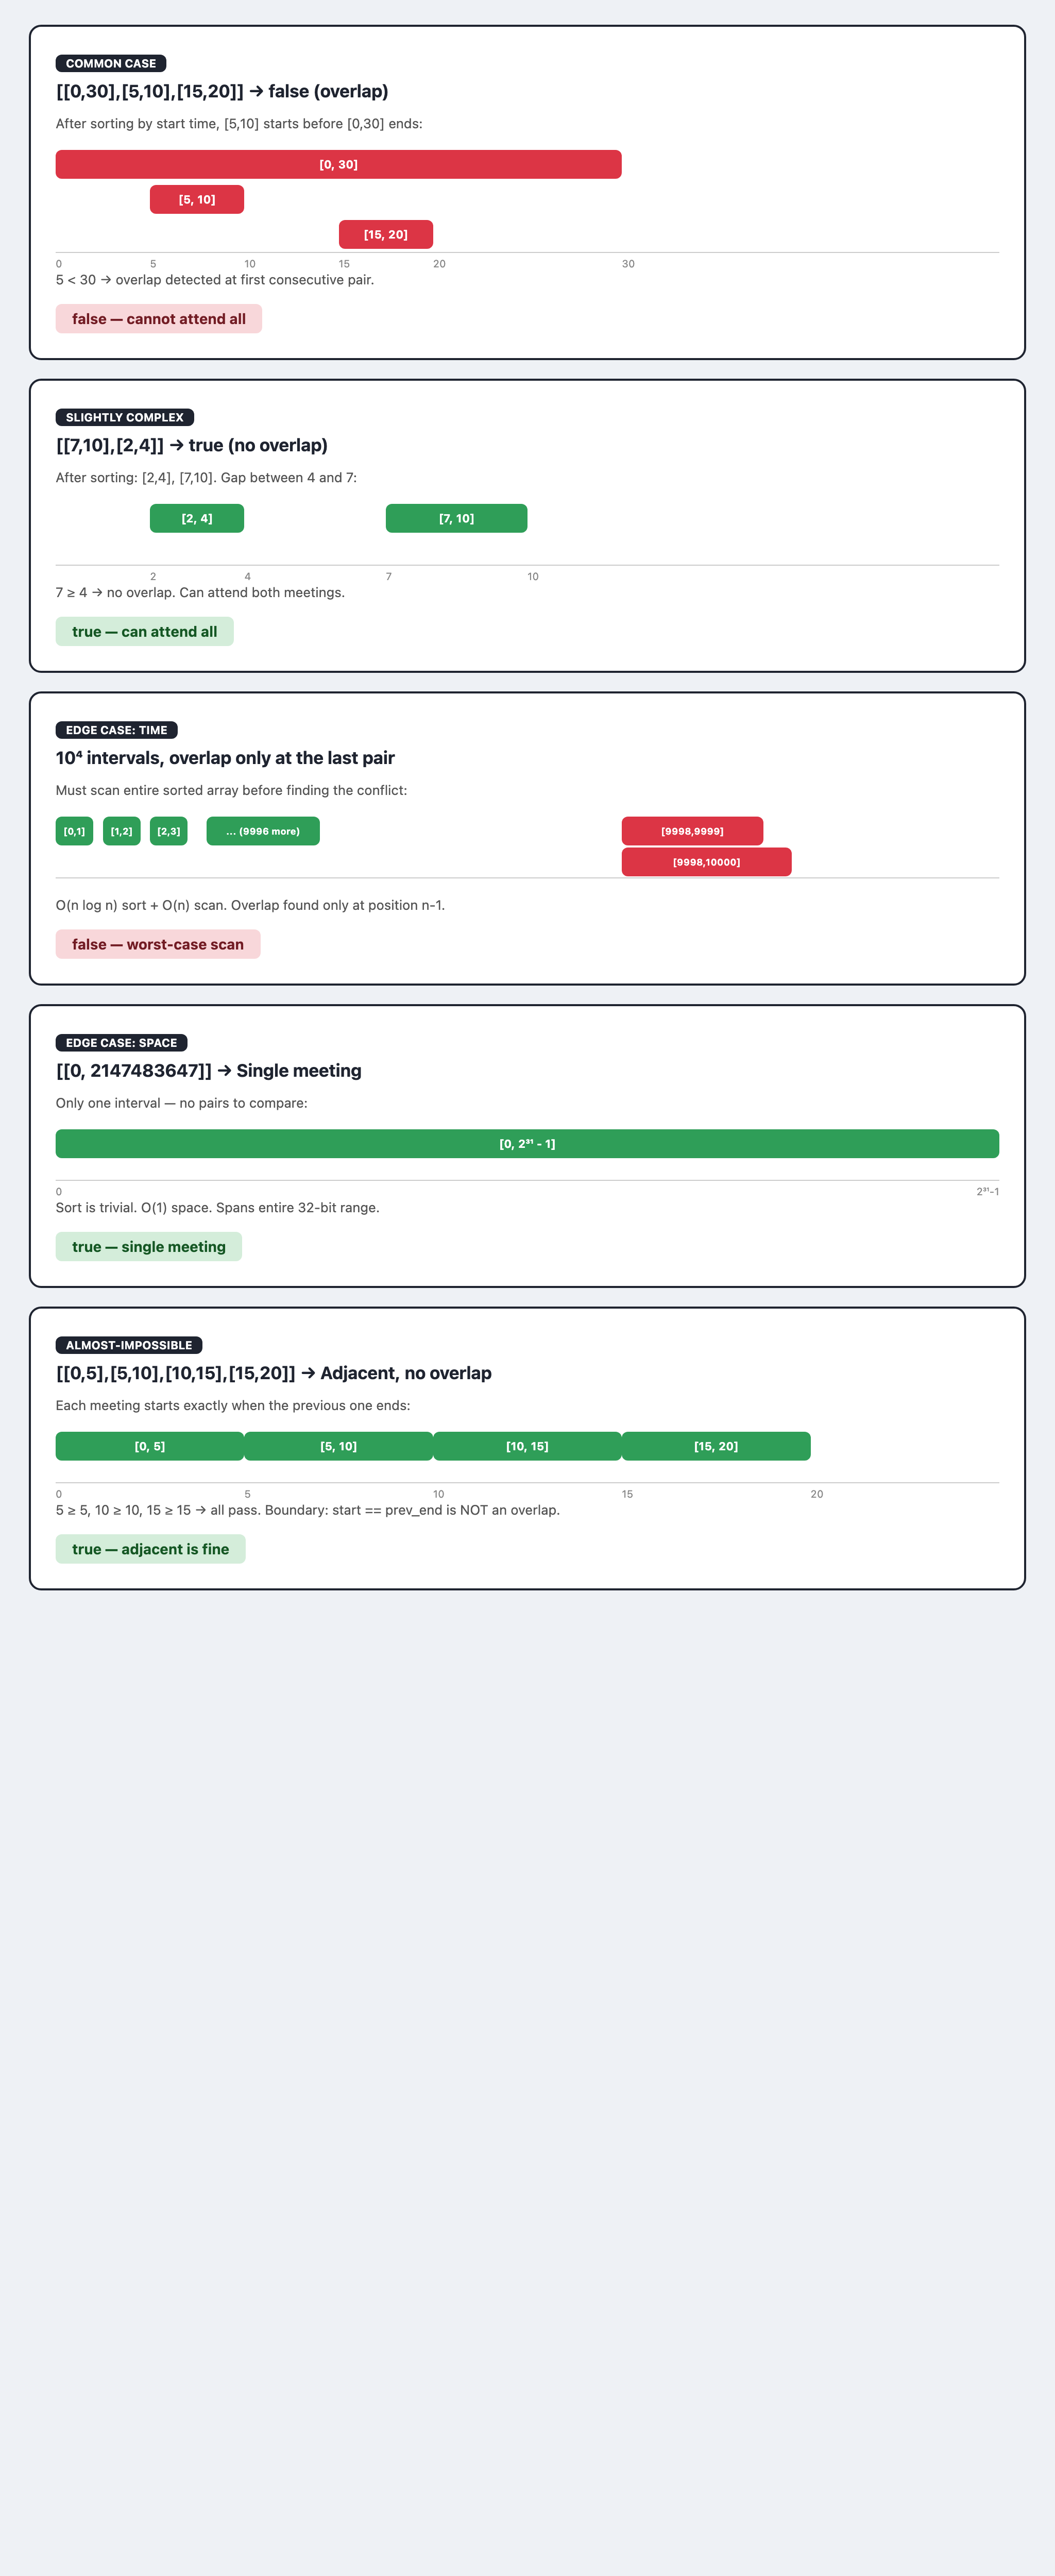